In [440]:
from pathlib import Path
import os

# Detectamos la ruta donde está guardado este notebook
notebook_dir = Path().resolve()
print(f"Directorio actual del notebook:\n{notebook_dir}\n")

# Cambiamos el directorio de trabajo a esta misma ruta
os.chdir(notebook_dir)

# Confirmamos
print(f"Nuevo directorio de trabajo:\n{os.getcwd()}")


Directorio actual del notebook:
C:\Users\kisza\Downloads\Códigos Pytohn\UNIDAD 4

Nuevo directorio de trabajo:
C:\Users\kisza\Downloads\Códigos Pytohn\UNIDAD 4


In [441]:
# === Librerías ===
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import requests, zipfile, io
import statsmodels.api as sm
# from ISLP import load_data   # Comentado: no está instalado y no se usa en el TP4

from sklearn.preprocessing import scale
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, LassoCV, Ridge, RidgeCV, ElasticNet, ElasticNetCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures 
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.tree import plot_tree
from sklearn.metrics import (
    confusion_matrix, accuracy_score, recall_score,
    roc_curve, roc_auc_score
)
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

# Configuración general
pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:,.2f}'.format
sns.set(style="whitegrid", palette="deep")

In [442]:
# Cargar base del TP3

#Traemos solo 2025 que lo limpiamos en el python anterior directamente
eph = pd.read_csv("eph_tp3.csv")


#La base cargada tiene algunas transformaciones adicionales. Se agregaron variables asociadas a características del jefe de hogar:
#jefe_ocupado, una dummy que toma 1 cuando el jefe de hogar de ese hogar está ocupado y se repite para todos sus miembros
#educ_jefe, una dummy que establece los años de educación del jefe de hogar para todos los miembros del hogar
#jefe_mujer,una dummy que establece si el/la jefe es mujer.
#ninos_hogar, cantidad de niños en el hogar


print("Base cargada correctamente.")
print("Filas y columnas:", eph.shape)
display(eph.head(10))


Base cargada correctamente.
Filas y columnas: (4057, 11)


,ch06,Sexo_Varón,educ,estado_Ocupado,cobertura_medica_tiene,pobre,estado_civil_no_casado,jefe_ocupado,educ_jefe,jefe_mujer,ninos_hogar
0,48,0,19.00,1,1,1,1,1,19.00,1,1
1,17,1,13.00,0,1,1,1,1,19.00,1,1
2,9,1,4.00,0,1,1,1,1,19.00,1,1
3,39,1,11.00,1,0,0,1,1,11.00,0,0
4,36,0,13.00,1,1,0,1,1,13.00,1,0
5,30,1,13.00,1,1,0,1,1,13.00,0,0
6,54,0,13.00,1,1,0,1,1,13.00,1,0
7,29,0,15.00,1,1,0,1,1,15.00,1,0
8,4,1,0.00,0,0,1,1,0,10.00,1,4
9,41,0,13.00,1,1,0,1,1,13.00,1,1


# A. Modelo de Regresión Logística con Regularización: Ridge y LASSO

## 1. Visualización de grilla de parámetros de penalidad - LASSO y Ridge

In [445]:
y = eph['pobre']

In [446]:
#Seleccionamos las variables numéricas para estandarizarlas, largando las dummies y la dependiente

# Columnas numéricas
cols_num = ['ch06', 'educ', 'educ_jefe',"ninos_hogar"]

# Columnas dummy
cols_dummy = ['Sexo_Varón',
              'estado_Ocupado',
              'cobertura_medica_tiene',
              'estado_civil_no_casado',
              'jefe_ocupado',
              'jefe_mujer']

X_num = eph[cols_num]
X_dummy = eph[cols_dummy]

X_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4057 entries, 0 to 4056
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ch06         4057 non-null   int64  
 1   educ         4057 non-null   float64
 2   educ_jefe    4057 non-null   float64
 3   ninos_hogar  4057 non-null   int64  
dtypes: float64(2), int64(2)
memory usage: 126.9 KB


In [447]:
X_num = X_num.reset_index(drop=True) # index original es descartado
X_num

,ch06,educ,educ_jefe,ninos_hogar
0,48,19.00,19.00,1
1,17,13.00,19.00,1
2,9,4.00,19.00,1
3,39,11.00,11.00,0
4,36,13.00,13.00,0
...,...,...,...,...
4052,55,13.00,13.00,0
4053,49,7.00,13.00,0
4054,35,7.00,13.00,0
4055,26,12.00,13.00,0


In [448]:
# Iniciamos el Standard Scaler
sc = StandardScaler()

# Estandarizamos las observaciones de entrenamiento
X_transformed = pd.DataFrame(sc.fit_transform(X_num),index=X_num.index, columns=X_num.columns)

X_transformed

,ch06,educ,educ_jefe,ninos_hogar
0,0.45,1.67,1.69,0.24
1,-0.95,0.44,1.69,0.24
2,-1.31,-1.40,1.69,0.24
3,0.05,0.03,-0.29,-0.77
4,-0.09,0.44,0.21,-0.77
...,...,...,...,...
4052,0.77,0.44,0.21,-0.77
4053,0.50,-0.79,0.21,-0.77
4054,-0.13,-0.79,0.21,-0.77
4055,-0.54,0.24,0.21,-0.77


In [449]:
X = pd.concat([X_transformed, X_dummy.astype(float)], axis=1)

X

,ch06,educ,educ_jefe,ninos_hogar,Sexo_Varón,estado_Ocupado,cobertura_medica_tiene,estado_civil_no_casado,jefe_ocupado,jefe_mujer
0,0.45,1.67,1.69,0.24,0.00,1.00,1.00,1.00,1.00,1.00
1,-0.95,0.44,1.69,0.24,1.00,0.00,1.00,1.00,1.00,1.00
2,-1.31,-1.40,1.69,0.24,1.00,0.00,1.00,1.00,1.00,1.00
3,0.05,0.03,-0.29,-0.77,1.00,1.00,0.00,1.00,1.00,0.00
4,-0.09,0.44,0.21,-0.77,0.00,1.00,1.00,1.00,1.00,1.00
...,...,...,...,...,...,...,...,...,...,...
4052,0.77,0.44,0.21,-0.77,0.00,0.00,1.00,1.00,0.00,1.00
4053,0.50,-0.79,0.21,-0.77,1.00,1.00,1.00,1.00,0.00,1.00
4054,-0.13,-0.79,0.21,-0.77,1.00,0.00,1.00,1.00,0.00,1.00
4055,-0.54,0.24,0.21,-0.77,0.00,1.00,1.00,1.00,0.00,1.00


In [450]:
# Train test split
X_train_regularizacion, X_test_regularizacion, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100, stratify=y)

# Revisamos cuantas observaciones quedaron para Test y cuantas para Entrenamiento.
print(f'El conjunto de entrenamiento tiene {len(X_train_regularizacion)} observaciones.')
print(f'El conjunto de test tiene {len(X_test_regularizacion)} observaciones.')

El conjunto de entrenamiento tiene 2839 observaciones.
El conjunto de test tiene 1218 observaciones.


In [451]:
# defino el espacio de lambdas
lambdas = np.logspace(-5, 5, 11)  

# Defino los C, que serán los lambdas de la regresión lineal
Cs = 1 / lambdas

In [452]:
coefs_ridge = []  
coefs_lasso = [] 

#Armo loops para recorrer los distintos valores de lambda

for C in Cs:
    #Ridge
    logit_ridge = LogisticRegression(penalty='l2',C=C,solver='lbfgs',max_iter=500)
    logit_ridge.fit(X_train_regularizacion, y_train)
    coefs_ridge.append(logit_ridge.coef_[0]) 

    # ----- LASSO (L1) -----
    logit_lasso = LogisticRegression(penalty='l1', C=C,solver='liblinear',max_iter=500)
    logit_lasso.fit(X_train_regularizacion, y_train)
    coefs_lasso.append(logit_lasso.coef_[0])

coefs_ridge = np.array(coefs_ridge)
coefs_lasso = np.array(coefs_lasso)

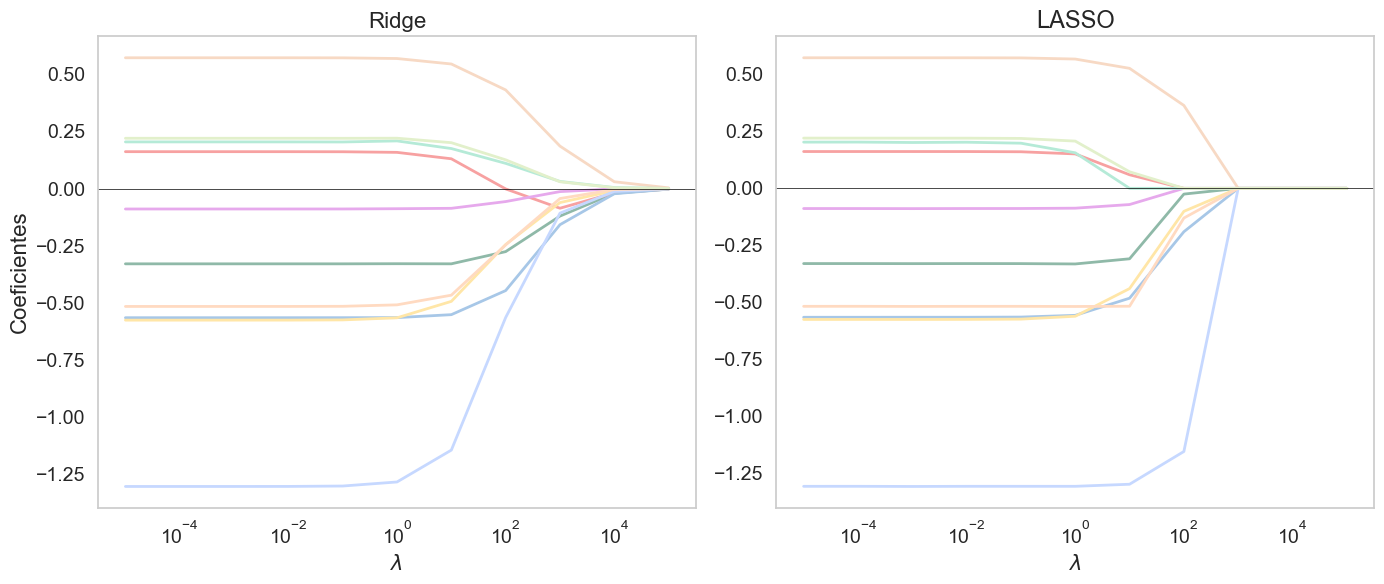

In [453]:
colores = [
    "#8FB9A8", "#F7A1A1", "#A7C7E7", "#F7D9C4", "#E6A9EC",
    "#FFE6A7", "#C6D8FF", "#B5EAD7", "#FFDAC1", "#E2F0CB"
]

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

#Ridge 
for i, col in enumerate(X_train_regularizacion.columns):
    axs[0].plot(lambdas, coefs_ridge[:, i], 
                color=colores[i % len(colores)], linewidth=2)
    
axs[0].set_xscale('log')
axs[0].set_xlabel(r'$\lambda$', fontsize=15)
axs[0].set_ylabel('Coeficientes',fontsize=16)
axs[0].set_title('Ridge',fontsize=16)
axs[0].axhline(0, color='black', linewidth=0.5)
axs[0].tick_params(axis='both', labelsize=14)
axs[0].grid(False)

#LASSO
for i, col in enumerate(X_train_regularizacion.columns):
    axs[1].plot(lambdas, coefs_lasso[:, i], 
                color=colores[i % len(colores)], linewidth=2)

axs[1].set_xscale('log')
axs[1].set_xlabel(r'$\lambda$',fontsize=15)
axs[1].set_title('LASSO',fontsize=17)
axs[1].axhline(0, color='black', linewidth=0.5)
axs[1].tick_params(axis='both', labelsize=14)
axs[1].grid(False)

plt.tight_layout()

plt.savefig("coeficientes_ridge_lasso.png", dpi=300, bbox_inches="tight")
plt.show()

In [454]:
#Matriz de Ridge para ver como se va comprimiendo los coeficientes a medida que aumenta lambda

coefs_ridge = []

for C in Cs:
    model = LogisticRegression(penalty='l2',C=C,solver='lbfgs', max_iter=500)
    model.fit(X_train_regularizacion, y_train)
    coefs_ridge.append(model.coef_[0])

coefs_ridge = np.array(coefs_ridge)
coefs_ridge

array([[-3.29524869e-01,  1.61530218e-01, -5.65433444e-01,
         5.72673610e-01, -8.94115220e-02, -5.76024793e-01,
        -1.30425466e+00,  2.04312462e-01, -5.16070678e-01,
         2.20282944e-01],
       [-3.29524881e-01,  1.61529896e-01, -5.65433327e-01,
         5.72673325e-01, -8.94114503e-02, -5.76023867e-01,
        -1.30425293e+00,  2.04312190e-01, -5.16070158e-01,
         2.20282765e-01],
       [-3.29525000e-01,  1.61526674e-01, -5.65432149e-01,
         5.72670480e-01, -8.94107331e-02, -5.76014606e-01,
        -1.30423566e+00,  2.04309471e-01, -5.16064949e-01,
         2.20280973e-01],
       [-3.29526194e-01,  1.61494462e-01, -5.65420373e-01,
         5.72642032e-01, -8.94035614e-02, -5.75922011e-01,
        -1.30406300e+00,  2.04282285e-01, -5.16012874e-01,
         2.20263055e-01],
       [-3.29537853e-01,  1.61172822e-01, -5.65302552e-01,
         5.72358055e-01, -8.93319017e-02, -5.74998209e-01,
        -1.30233959e+00,  2.04010693e-01, -5.15492898e-01,
         2.

In [455]:
#Matriz de Lasso. En este caso se ve como se van haciendo cero

coefs_lasso = []

for C in Cs:
    model = LogisticRegression(penalty='l1',C=C,solver='liblinear',max_iter=500)
    model.fit(X_train_regularizacion, y_train)
    coefs_lasso.append(model.coef_[0])

coefs_lasso = np.array(coefs_lasso)
coefs_lasso

array([[-0.32980987,  0.16137759, -0.56528894,  0.57245223, -0.08857483,
        -0.57482544, -1.30638024,  0.20279456, -0.51724632,  0.22017358],
       [-0.33013013,  0.16135114, -0.56517682,  0.57240068, -0.08888331,
        -0.57485349, -1.30697915,  0.20108845, -0.51787119,  0.21991884],
       [-0.33014778,  0.16134404, -0.5651783 ,  0.57239482, -0.08896333,
        -0.57485681, -1.307071  ,  0.2008895 , -0.51780396,  0.21999242],
       [-0.33018894,  0.16127243, -0.56508852,  0.57235196, -0.08898261,
        -0.57475639, -1.30721083,  0.20044335, -0.51800109,  0.21969484],
       [-0.33027687,  0.16029794, -0.56433835,  0.57184039, -0.08871963,
        -0.5734518 , -1.30699975,  0.19640546, -0.51785405,  0.21872984],
       [-0.33155012,  0.15089437, -0.55684578,  0.56686067, -0.08693171,
        -0.56081313, -1.30640436,  0.15573544, -0.51798466,  0.20707948],
       [-0.3089127 ,  0.05949937, -0.48153725,  0.52614072, -0.07140368,
        -0.43955699, -1.29787587,  0.        

In [456]:
# Crear DataFrame con índices = lambdas y columnas = variables
df_ridge = pd.DataFrame(coefs_ridge, columns=X_train_regularizacion.columns, index=Cs)
df_lasso = pd.DataFrame(coefs_lasso, columns=X_train_regularizacion.columns, index=Cs)

df_ridge.index.name = "C (1/λ)"
df_lasso.index.name = "C (1/λ)"

df_lasso.index = lambdas
df_lasso.index.name = "λ"

df_ridge  # Ridge
df_lasso  # LASSO

with pd.ExcelWriter("coeficientes_ridge_lasso.xlsx") as writer:
    df_ridge.to_excel(writer, sheet_name="Ridge")
    df_lasso.to_excel(writer, sheet_name="LASSO")

## 2.Penalidad óptima por Cross-validation y visualización

In [458]:
# Ridge

kf = KFold(n_splits=5, shuffle=True, random_state=100)

resultados = []

for C in Cs:
    errores = []
    
    for train_index, val_index in kf.split(X_train_regularizacion):
        X_tr, X_val = X_train_regularizacion.iloc[train_index], X_train_regularizacion.iloc[val_index]
        y_tr, y_val = y_train.iloc[train_index], y_train.iloc[val_index]

        modelo = LogisticRegression(penalty='l2', C=C, solver='lbfgs', max_iter=500)
        modelo.fit(X_tr, y_tr)
        prediccion = modelo.predict(X_val)
        
        acc = accuracy_score(y_val, prediccion)
        error = 1 - acc
        errores.append(error)
    
    resultados.append(np.mean(errores))

mejor_ridge = np.argmin(resultados)
mejor_lambda_ridge = lambdas[mejor_ridge]
mejor_error_ridge = resultados[mejor_ridge]

print("Mejor lambda en Ridge:", mejor_lambda_ridge)
print("Menor error de clasificación en Ridge:", round(mejor_error_ridge, 4))

Mejor lambda en Ridge: 10.0
Menor error de clasificación en Ridge: 0.1733


In [459]:
# LASSO
kf = KFold(n_splits=5, shuffle=True, random_state=100)

resultados_lasso = []

for C in Cs:
    errores = []    
    for train_index, val_index in kf.split(X_train_regularizacion):
        X_tr, X_val = X_train_regularizacion.iloc[train_index], X_train_regularizacion.iloc[val_index]
        y_tr, y_val = y_train.iloc[train_index], y_train.iloc[val_index]

        modelo = LogisticRegression(penalty='l1',C=C,solver='liblinear',max_iter=500)
        modelo.fit(X_tr, y_tr)
        prediccion = modelo.predict(X_val)
        
        acc = accuracy_score(y_val, prediccion)
        error = 1 - acc
        errores.append(error)
    
    resultados_lasso.append(np.mean(errores))

mejor_lasso = np.argmin(resultados_lasso)
mejor_lambda_lasso = lambdas[mejor_lasso]
mejor_error_lasso = resultados_lasso[mejor_lasso]

print("Mejor lambda en LASSO:", mejor_lambda_lasso)
print("Menor error de clasificación en LASSO:", round(mejor_error_lasso, 4))

Mejor lambda en LASSO: 0.1
Menor error de clasificación en LASSO: 0.174


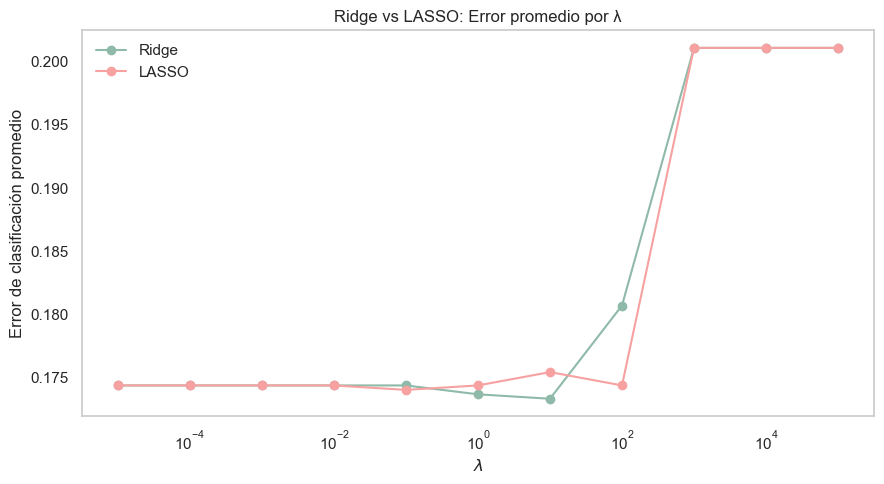

In [460]:
plt.figure(figsize=(9,5))
color_ridge = '#8FB9A8'   
color_lasso = '#F7A1A1'  

plt.plot(lambdas, resultados, marker='o', linestyle='-', label='Ridge', color=color_ridge)
plt.plot(lambdas, resultados_lasso, marker='o', linestyle='-', label='LASSO', color=color_lasso)

plt.xscale('log')
plt.xlabel(r'$\lambda$')
plt.ylabel('Error de clasificación promedio')
plt.title('Ridge vs LASSO: Error promedio por λ')

plt.legend(loc='upper left', frameon=False)   # ← aquí cambia la posición

plt.grid(False)
plt.tight_layout()
plt.savefig("error de clasificación según costo de complejidad.png", dpi=300, bbox_inches="tight")
plt.show()

## 3.Estimación con lambda por cross-validation y comparación de coeficientes

In [462]:
logit = LogisticRegression(solver='lbfgs',max_iter=1000)
logit.fit(X_train_regularizacion, y_train)
coef_logit = logit.coef_[0]


lasso = LogisticRegression(penalty='l1',C=1/mejor_lambda_lasso,solver='liblinear', max_iter=1000)
lasso.fit(X_train_regularizacion, y_train)
coef_lasso = lasso.coef_[0]


ridge = LogisticRegression(penalty='l2', C=1/mejor_lambda_ridge,solver='lbfgs',max_iter=1000)
ridge.fit(X_train_regularizacion, y_train)
coef_ridge = ridge.coef_[0]

In [463]:
tabla_coef = pd.DataFrame({"Logit": coef_logit,"LASSO": coef_lasso,"Ridge": coef_ridge
}, index=X_train_regularizacion.columns)

tabla_coef.round(4)

,Logit,LASSO,Ridge
ch06,-0.33,-0.33,-0.33
educ,0.16,0.16,0.13
educ_jefe,-0.56,-0.56,-0.55
ninos_hogar,0.57,0.57,0.55
Sexo_Varón,-0.09,-0.09,-0.09
estado_Ocupado,-0.57,-0.57,-0.49
cobertura_medica_tiene,-1.28,-1.31,-1.15
estado_civil_no_casado,0.21,0.20,0.18
jefe_ocupado,-0.51,-0.52,-0.47
jefe_mujer,0.22,0.22,0.20


In [464]:
tabla_coef.to_excel("coeficientes_logit_lasso_ridge.xlsx", index=True)

# B. Árboles de Decisión

## 4. Árbol podado con Cross-Validation (10-fold)

In [467]:
# Generar la grilla de ccp_alpha 
# Grilla de valores para ccp_alpha (log-spaced)
ccp_grid = np.logspace(-5, 0, 20)   

In [468]:
#Volvemos a separar en train y test ya que las X numéricas anteriores habían quedado escalados para regularización
eph = eph.rename(columns={"ch06": "edad"})
X = eph.drop(columns=["pobre"]) # a y ya la definimos al principio como pobre y no la habíamos escalado por ser dummy

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100,stratify=y)

# Cross-validation 10-fold para seleccionar el mejor alpha 
cv_errors = []

for alpha in ccp_grid:
    tree = DecisionTreeClassifier(random_state=100, ccp_alpha=alpha)
    scores = cross_val_score(tree, X_train, y_train, cv=10, scoring="accuracy")
    
    # Error de clasificación = 1 - accuracy
    cv_errors.append(1 - scores.mean())

cv_errors = np.array(cv_errors)

best_alpha = ccp_grid[np.argmin(cv_errors)]
print("Mejor alpha:", best_alpha)

Mejor alpha: 0.002335721469090121


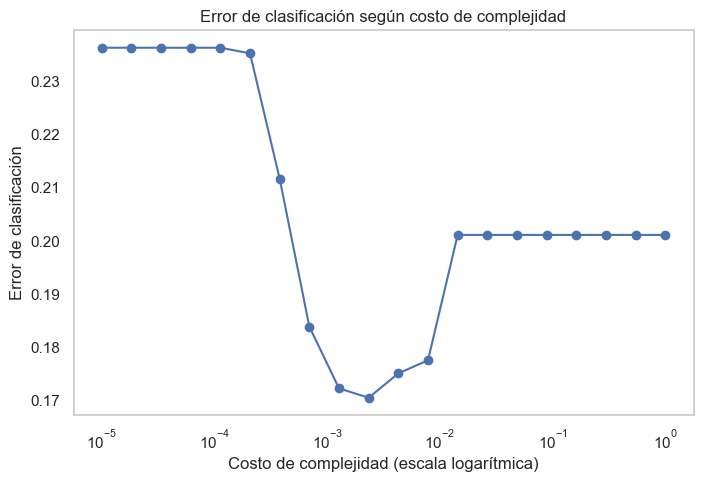

Mejor ccp_alpha según CV: 0.002335721469090121


In [469]:
# Gráfico del error en función de ccp_alpha 
plt.figure(figsize=(8,5))
plt.plot(ccp_grid, cv_errors, marker="o")
plt.xscale("log")
plt.xlabel("Costo de complejidad (escala logarítmica)")
plt.ylabel("Error de clasificación")
plt.title("Error de clasificación según costo de complejidad")
plt.grid(False)
plt.savefig("error de clasificación según complejidad.png", dpi=300, bbox_inches="tight")
plt.show()

print("Mejor ccp_alpha según CV:", best_alpha)

In [470]:
#No está en la consigna pero buscamos también el mejor max_depth

depth_errors = []

# definí la grilla de profundidades que quieras evaluar
depth_grid = range(1, 21)   # por ejemplo de 1 a 20

for depth in depth_grid:
    tree = DecisionTreeClassifier(random_state=100, max_depth=depth)
    scores = cross_val_score(tree, X_train, y_train, cv=10, scoring="accuracy")
    
    # Error de clasificación = 1 - accuracy
    depth_errors.append(1 - scores.mean())

depth_errors = np.array(depth_errors)

best_depth = depth_grid[np.argmin(depth_errors)]
print("Mejor max_depth:", best_depth)

Mejor max_depth: 4


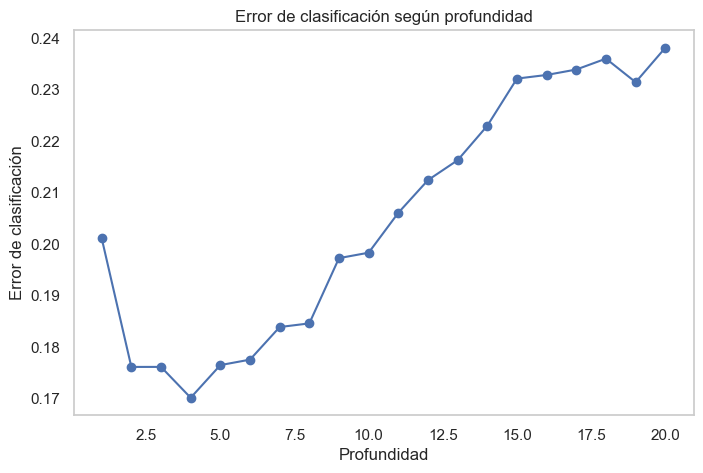

Mejor profundidad según CV: 4


In [471]:
# Gráfico del error en función de ccp_alpha 
plt.figure(figsize=(8,5))
plt.plot(depth_grid, depth_errors, marker="o")
plt.xlabel("Profundidad")
plt.ylabel("Error de clasificación")
plt.title("Error de clasificación según profundidad")
plt.grid(False)
plt.savefig("eror de calisificación según profundidad.png", dpi=300, bbox_inches="tight")

plt.show()

print("Mejor profundidad según CV:", best_depth)

## 5. Visualización del árbol podado + Importancia de predictores

In [473]:
# Entrenar el CART final con el mejor alpha 
tree_pruned = DecisionTreeClassifier(random_state=100, ccp_alpha=best_alpha, max_depth=best_depth)
tree_pruned.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.002335721469090121, max_depth=4,
                       random_state=100)

In [558]:
rename_dict = {
    "edad": "Edad",
    "educ": "Años de educación",
    "educ_jefe": "Educación del jefe del hogar",
    "ninos_hogar": "Cantidad de niños en el hogar",
    "Sexo_Varón": "Sexo (varón)",
    "estado_Ocupado": "Ocupado",
    "cobertura_medica_tiene": "Posee cobertura médica",
    "estado_civil_no_casado": "Estado civil (no casado)",
    "jefe_ocupado": "Jefe de hogar ocupado",
    "jefe_mujer": "Jefe de hogar mujer"
}


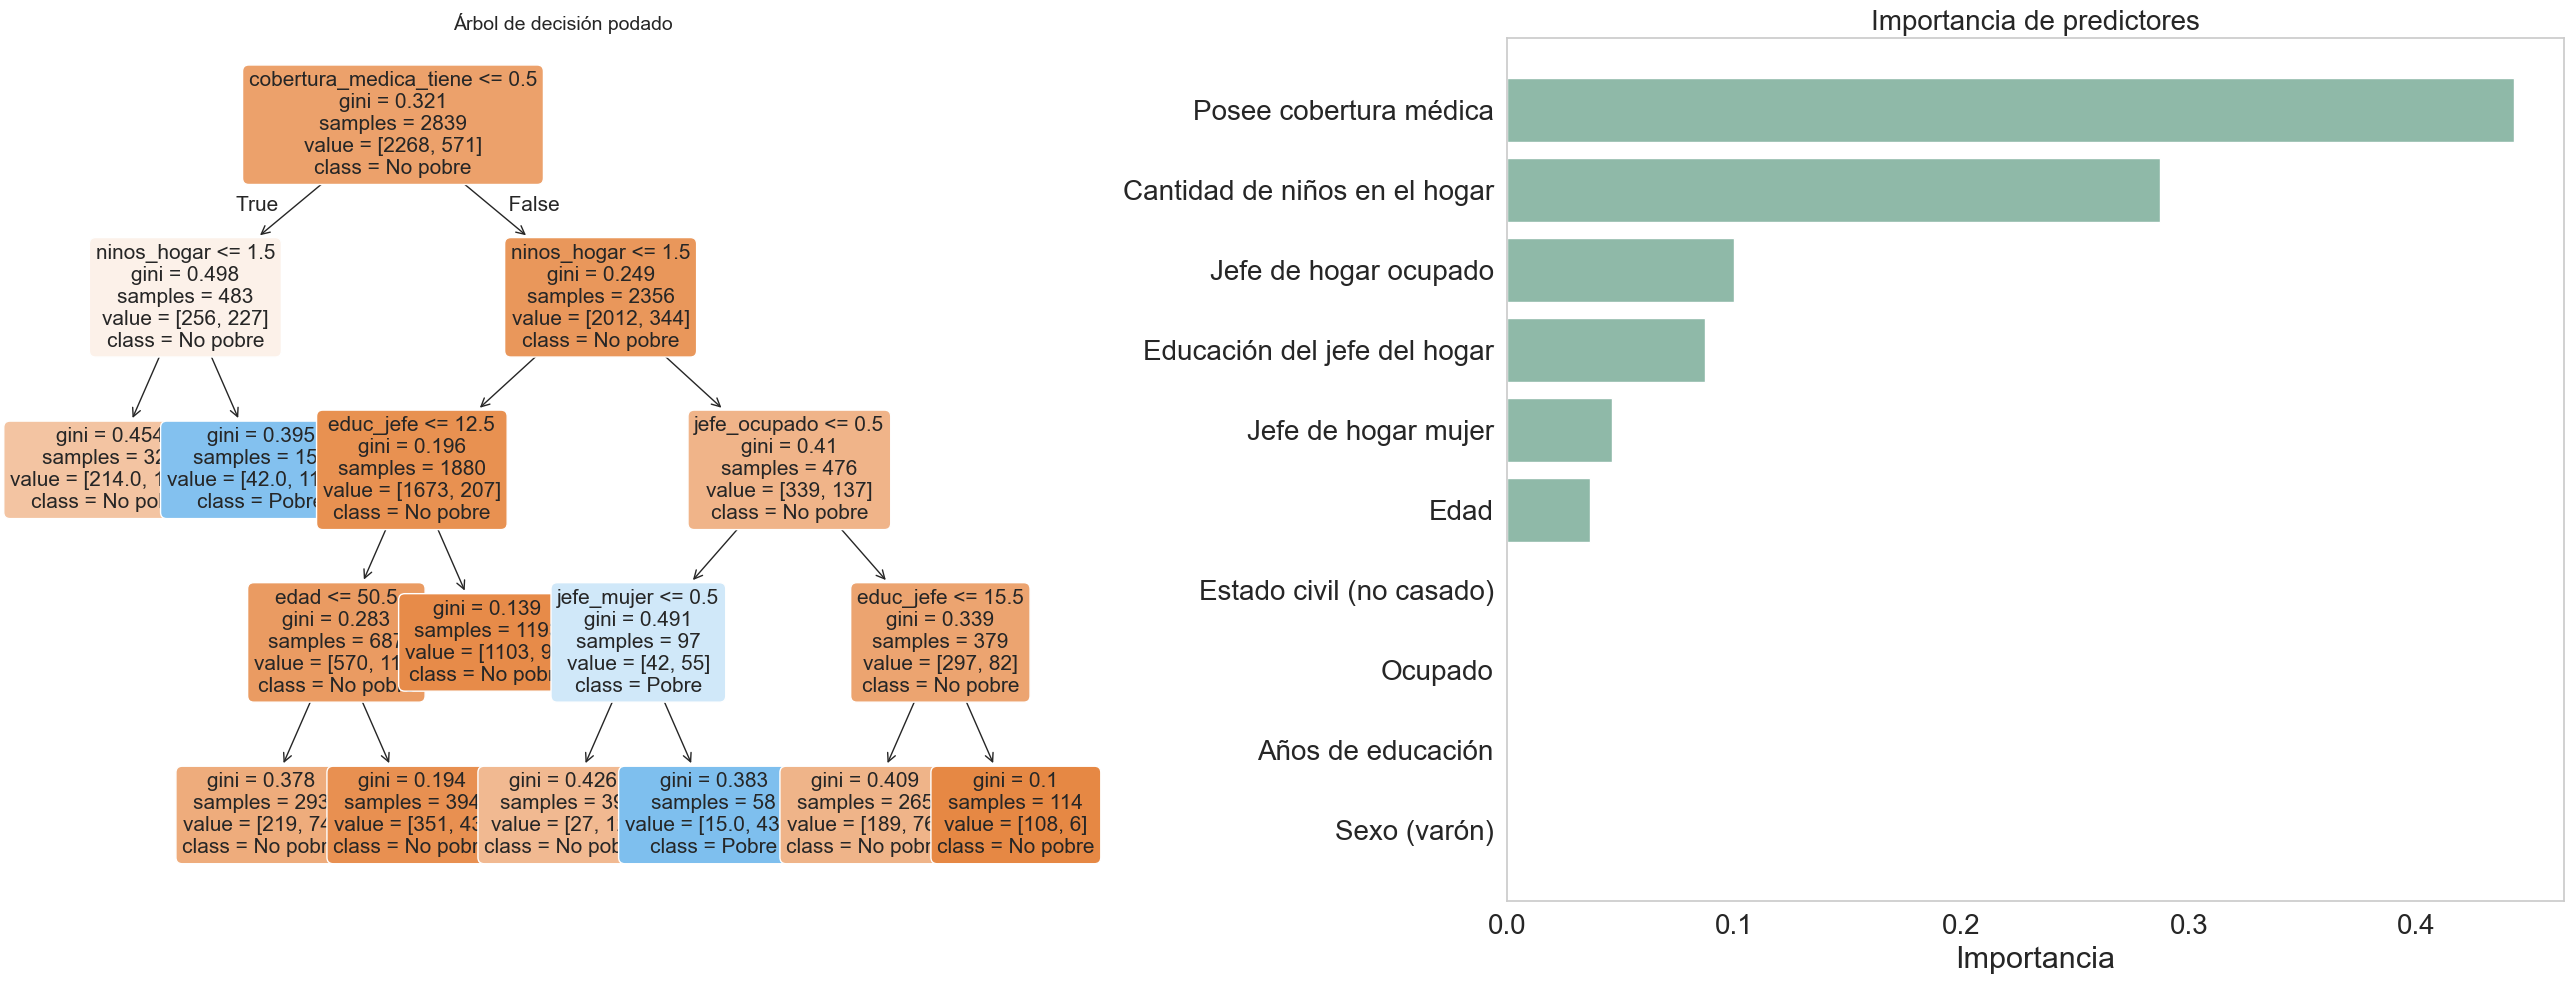

In [560]:

# Importancia de predictores
importancias = tree_pruned.feature_importances_

importancias_df = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": importancias
}).sort_values("Importancia", ascending=True)

importancias_df["Variable"] = importancias_df["Variable"].replace(rename_dict)

fig, axes = plt.subplots(1, 2, figsize=(26, 10))

# Panel A: Árbol de decisión
plot_tree(
    tree_pruned,
    feature_names=X_train.columns,
    class_names=["No pobre", "Pobre"],
    filled=True,
    rounded=True,
    fontsize=15,
    ax=axes[0]
)
axes[0].set_title("Árbol de decisión podado", fontsize=14)

# Panel B: Importancia de predictores
axes[1].barh(
    importancias_df["Variable"],
    importancias_df["Importancia"],
    color="#8FB9A8"
)
axes[1].set_title("Importancia de predictores", fontsize=20)
axes[1].set_xlabel("Importancia", fontsize=22)
axes[1].grid(False)
axes[1].tick_params(axis='both', labelsize=20)

plt.tight_layout()
plt.savefig("arbol de decisión y predictores.png", dpi=300, bbox_inches="tight")
plt.show()

In [475]:
#Tabla
importancias_df.sort_values("Importancia", ascending=False)

,Variable,Importancia
4,cobertura_medica_tiene,0.44
9,ninos_hogar,0.29
6,jefe_ocupado,0.10
7,educ_jefe,0.09
8,jefe_mujer,0.05
0,edad,0.04
1,Sexo_Varón,0.00
2,educ,0.00
3,estado_Ocupado,0.00
5,estado_civil_no_casado,0.00


# C. Comparación entre métodos

## 6. Matriz de confusión, curva ROC y métricas

### Entrenamos el LOGIT

In [479]:
# Train–test split 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=100,
    stratify=y
)

# Estimación de la regresión logística (Logit)

# Agregamos constante solo para el Logit
X_train_logit = sm.add_constant(X_train, prepend=True)
X_test_logit = sm.add_constant(X_test, prepend=True)

logit_model = sm.Logit(y_train, X_train_logit)
logit_results = logit_model.fit()

Optimization terminated successfully.
         Current function value: 0.400360
         Iterations 6


### Matriz de confusión del Logit

In [481]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score


# Predicciones de probabilidad con el modelo Logit
y_pred_prob_logit = logit_results.predict(X_test_logit)

# Umbral de clasificación
umbral = 0.5
y_pred_logit = (y_pred_prob_logit > umbral).astype(int)

# Matriz de confusión para Logit
cm_logit = confusion_matrix(y_test, y_pred_logit)

print("=== Matriz de confusión – Logit (umbral 0.5) ===")
print(cm_logit)


cm_df = pd.DataFrame(cm_logit,
                     index=["No pobre (Real)", "Pobre (Real)"],
                     columns=["No pobre (Pred)", "Pobre (Pred)"])

print("\nTabla de matriz de confusión:")
print(cm_df)

# exportar a Excel
cm_df.to_excel("matriz_confusion_logit.xlsx", index=True)


=== Matriz de confusión – Logit (umbral 0.5) ===
[[918  55]
 [163  82]]

Tabla de matriz de confusión:
                 No pobre (Pred)  Pobre (Pred)
No pobre (Real)              918            55
Pobre (Real)                 163            82


### Entrenamos el KNNN

In [483]:
# Selección de K óptimo por Cross-Validation
ks = range(1, 11)
accuracy_cv = []
kf = KFold(n_splits=5, shuffle=True, random_state=100)

for k in ks:
    knn_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(knn_pipe, X_train, y_train, cv=kf, scoring="accuracy")
    accuracy_cv.append(scores.mean())

k_optimo = ks[np.argmax(accuracy_cv)]
print("K óptimo según CV:", k_optimo)


K óptimo según CV: 4


### Matriz de confusión del KNN

In [485]:
# Entrenamos el KNN óptimo en el set de entrenamiento

modelo_knn_opt = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=k_optimo))
])
modelo_knn_opt.fit(X_train, y_train)

# Probabilidades predichas de pobreza en el test
y_pred_prob_knn = modelo_knn_opt.predict_proba(X_test)[:, 1]

# Para comparación, también matriz de confusión de KNN con umbral 0.5
y_pred_knn = (y_pred_prob_knn > 0.5).astype(int)
cm_knn = confusion_matrix(y_test, y_pred_knn)

print("\n=== Matriz de confusión – KNN (K óptimo, umbral 0.5) ===")
print(cm_knn)

cm_df = pd.DataFrame(cm_knn,
                     index=["No pobre (Real)", "Pobre (Real)"],
                     columns=["No pobre (Pred)", "Pobre (Pred)"])

print("\nTabla de matriz de confusión:")
print(cm_df)

# exportar a Excel
cm_df.to_excel("matriz_confusion_knn.xlsx", index=True)


=== Matriz de confusión – KNN (K óptimo, umbral 0.5) ===
[[938  35]
 [172  73]]

Tabla de matriz de confusión:
                 No pobre (Pred)  Pobre (Pred)
No pobre (Real)              938            35
Pobre (Real)                 172            73


### Estimamos Ridge con lambda obtenido antes

In [487]:
# Ridge 
C_best = 1 / mejor_lambda_ridge

ridge = LogisticRegression(
    penalty='l2',
    C=C_best,
    solver='lbfgs',
    max_iter=2000
)
ridge.fit(X_train_regularizacion, y_train)


LogisticRegression(C=0.1, max_iter=2000)

### Matriz de Confusión Ridge

In [489]:
y_pred_prob_ridge = ridge.predict_proba(X_test_regularizacion)[:,1]
y_pred_ridge = (y_pred_prob_ridge > 0.5).astype(int)

cm_ridge = confusion_matrix(y_test, y_pred_ridge)
print(pd.DataFrame(cm_ridge,
    index=["No pobre (Real)","Pobre (Real)"],
    columns=["No pobre (Pred)", "Pobre (Pred)"]))

                 No pobre (Pred)  Pobre (Pred)
No pobre (Real)              923            50
Pobre (Real)                 170            75


### Estimamos LASSO con lambda obtenido antes

In [491]:
# Modelo LASSO (penalidad L1)
C_best = 1/mejor_lambda_lasso

lasso = LogisticRegression(
    penalty="l1",
    solver="liblinear",  # necesario para L1
    max_iter=1000,
    C=C_best
)
lasso.fit(X_train_regularizacion, y_train)

LogisticRegression(C=10.0, max_iter=1000, penalty='l1', solver='liblinear')

### Matriz de confusión Lasso

In [493]:
# Probabilidades y clases predichas
y_pred_prob_lasso = lasso.predict_proba(X_test_regularizacion)[:, 1]
y_pred_lasso = (y_pred_prob_lasso > 0.5).astype(int)

# Matriz de confusión
cm_lasso = confusion_matrix(y_test, y_pred_lasso)

cm_lasso_df = pd.DataFrame(
    cm_lasso,
    index=["No pobre (Real)", "Pobre (Real)"],
    columns=["No pobre (Pred)", "Pobre (Pred)"]
)

print("\n=== Matriz de confusión – Logit LASSO (umbral 0.5) ===")
print(cm_lasso_df)


=== Matriz de confusión – Logit LASSO (umbral 0.5) ===
                 No pobre (Pred)  Pobre (Pred)
No pobre (Real)              918            55
Pobre (Real)                 163            82


### Estimación arbol de decisión y matriz de confusión

In [495]:
y_pred_tree = tree_pruned.predict(X_test)


y_pred_prob_tree = tree_pruned.predict_proba(X_test)[:, 1]
y_pred_tree = (y_pred_prob_tree > 0.5).astype(int)

cm_tree = confusion_matrix(y_test, y_pred_tree)

cm_tree_df = pd.DataFrame(
    cm_tree,
    index=["No pobre (Real)", "Pobre (Real)"],
    columns=["No pobre (Pred)", "Pobre (Pred)"]
)

print("\n=== Matriz de confusión – Árbol de decisión podado ===")
print(cm_tree_df)


=== Matriz de confusión – Árbol de decisión podado ===
                 No pobre (Pred)  Pobre (Pred)
No pobre (Real)              935            38
Pobre (Real)                 176            69


### Todo junto y sumamos las métricas

In [497]:

modelos = {
    "Logit": (y_pred_prob_logit, y_pred_logit),
    f"KNN (K={k_optimo})": (y_pred_prob_knn, y_pred_knn),
    "Logit Ridge": (y_pred_prob_ridge, y_pred_ridge),
    "Logit LASSO": (y_pred_prob_lasso, y_pred_lasso),
    "Árbol podado": (y_pred_prob_tree, y_pred_tree)
}

resultados = []

for nombre, (prob, pred) in modelos.items():
    # Matriz de confusión
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Métricas
    acc = accuracy_score(y_test, pred)
    rec = recall_score(y_test, pred)          # pobreza = 1
    auc = roc_auc_score(y_test, prob)
    
    resultados.append({
        "Modelo": nombre,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Accuracy": acc,
        "Recall (pobre=1)": rec,
        "AUC": auc
    })

tabla_resultados = pd.DataFrame(resultados)
print(tabla_resultados)

# Si querés exportar:
tabla_resultados.to_excel("resultados_todos_modelos.xlsx", index=False)

         Modelo   TN  FP   FN  TP  Accuracy  Recall (pobre=1)  AUC
0         Logit  918  55  163  82      0.82              0.33 0.80
1     KNN (K=4)  938  35  172  73      0.83              0.30 0.75
2   Logit Ridge  923  50  170  75      0.82              0.31 0.80
3   Logit LASSO  918  55  163  82      0.82              0.33 0.80
4  Árbol podado  935  38  176  69      0.82              0.28 0.75


### Curvas ROC

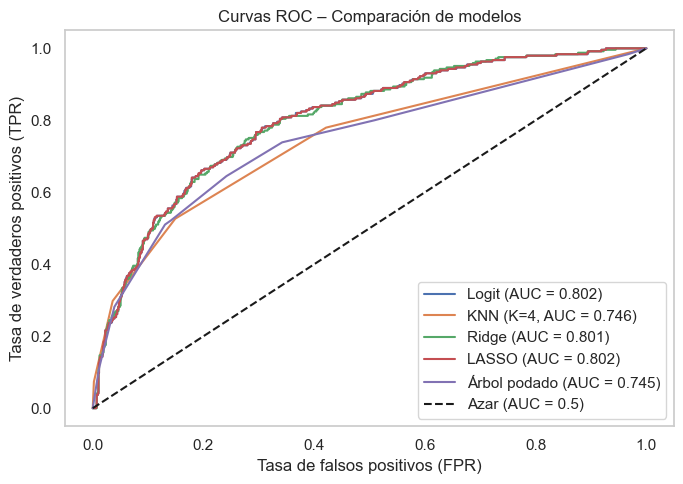

In [499]:
plt.figure(figsize=(7, 5))

# LOGIT
fpr_logit, tpr_logit, _ = roc_curve(y_test, y_pred_prob_logit)
auc_logit = roc_auc_score(y_test, y_pred_prob_logit)
plt.plot(fpr_logit, tpr_logit, label=f"Logit (AUC = {auc_logit:.3f})")

# KNN
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_pred_prob_knn)
auc_knn = roc_auc_score(y_test, y_pred_prob_knn)
plt.plot(fpr_knn, tpr_knn, label=f"KNN (K={k_optimo}, AUC = {auc_knn:.3f})")

# RIDGE
fpr_ridge, tpr_ridge, _ = roc_curve(y_test, y_pred_prob_ridge)
auc_ridge = roc_auc_score(y_test, y_pred_prob_ridge)
plt.plot(fpr_ridge, tpr_ridge, label=f"Ridge (AUC = {auc_ridge:.3f})")

# LASSO
fpr_lasso, tpr_lasso, _ = roc_curve(y_test, y_pred_prob_lasso)
auc_lasso = roc_auc_score(y_test, y_pred_prob_lasso)
plt.plot(fpr_lasso, tpr_lasso, label=f"LASSO (AUC = {auc_lasso:.3f})")

# ÁRBOL PODADO
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_pred_prob_tree)
auc_tree = roc_auc_score(y_test, y_pred_prob_tree)
plt.plot(fpr_tree, tpr_tree, label=f"Árbol podado (AUC = {auc_tree:.3f})")

# Línea base
plt.plot([0, 1], [0, 1], "k--", label="Azar (AUC = 0.5)")

# Etiquetas
plt.xlabel("Tasa de falsos positivos (FPR)")
plt.ylabel("Tasa de verdaderos positivos (TPR)")
plt.title("Curvas ROC – Comparación de modelos")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.savefig("curvas ROC.png", dpi=300, bbox_inches="tight")
plt.show()